# Run cells from AllenDB

#choose specimen id and model type

In [1]:
import os, sys, json
import matplotlib.pyplot as plt
import numpy as np

sys.path.append("../../../../mods/ACT")
from act.passive import ACTPassiveModule

# sys.path.append("/home/hrbncv/PV-SST/single_cells")
sys.path.append('../..')
from modules import download_cell


#Download the cell -  if using HOC: upload the hoc template to the working directory and modfiles into a folder named 'modfiles' and skip to 'Build the Cell' then 'Simulation Parameters'

In [2]:
# Mouse L2/3 SST (Som) cell
# http://celltypes.brain-map.org/mouse/experiment/electrophysiology/485466109
specimen_id = 485466109

model_type = 'perisomatic'#or 'all active'
work_dir = 'OriginalFromAllenDB'

In [ ]:
# (Optional) list available bundles for a specimen
download_cell.list_ADB_models(specimen_id)                             # all
download_cell.list_ADB_models(specimen_id, filter_type=model_type)  # filtered

# Download a bundle
out = download_cell.download_ADB_cell(
    specimen_id=specimen_id,
    model_type=model_type,          # or "all active"
    work_dir=work_dir,    # base dir
    cache_stimulus=False,              # skip big NWB
    subdir=True,          # saves in 'work_dir'/'specimen_id'_'model_type'
    match="contains",                  # name matching behavior
    quiet=False,
)
out["model_id"], out["model_name"], out["work_dir"]

# List the files you just pulled
len(out["files"]), out["files"][:5]

Models for specimen_id=485466109:
  496538951  Biophysical - all active_Sst-IRES-Cre;Ai14-202729.03.02.01
  485720616  Biophysical - perisomatic_Sst-IRES-Cre;Ai14-202729.03.02.01
Models for specimen_id=485466109:
  485720616  Biophysical - perisomatic_Sst-IRES-Cre;Ai14-202729.03.02.01


2025-08-20 16:27:37,079 allensdk.api.api.retrieve_file_over_http INFO     Downloading URL: http://api.brain-map.org/api/v2/well_known_file_download/496079508
2025-08-20 16:27:37,362 allensdk.api.api.retrieve_file_over_http INFO     Downloading URL: http://api.brain-map.org/api/v2/well_known_file_download/496605076
2025-08-20 16:27:37,543 allensdk.api.api.retrieve_file_over_http INFO     Downloading URL: http://api.brain-map.org/api/v2/well_known_file_download/395337293
2025-08-20 16:27:37,730 allensdk.api.api.retrieve_file_over_http INFO     Downloading URL: http://api.brain-map.org/api/v2/well_known_file_download/395337054
2025-08-20 16:27:37,873 allensdk.api.api.retrieve_file_over_http INFO     Downloading URL: http://api.brain-map.org/api/v2/well_known_file_download/395337225
2025-08-20 16:27:38,013 allensdk.api.api.retrieve_file_over_http INFO     Downloading URL: http://api.brain-map.org/api/v2/well_known_file_download/395337019
2025-08-20 16:27:38,163 allensdk.api.api.retrieve_fi

Downloaded model_id=485720616 (Biophysical - perisomatic_Sst-IRES-Cre;Ai14-202729.03.02.01) for specimen_id=485466109
→ OriginalFromAllenDB/485466109_perisomatic  | files: 20  | cache_stimulus=False


(485720616,
 'Biophysical - perisomatic_Sst-IRES-Cre;Ai14-202729.03.02.01',
 'OriginalFromAllenDB/485466109_perisomatic')

In [ ]:
spec_dir = f'{work_dir}/{specimen_id}_{model_type}'
os.chdir(spec_dir)

'/home/hrbncv/PV-SST/single_cells/cells/extra/OriginalFromAllenDB/485466109_perisomatic'

## Build the cell

if you need additonal modfiles from a public repo, provide a list of the names of the modfiles and a link to the folder

In [6]:
# Compile the modfiles (make sure to update with tuned modfiles and json)
!nrnivmodl modfiles > /dev/null 2>&1

In [8]:
import sys, os
from functools import wraps

def suppress_output(fn):
    @wraps(fn)
    def wrapper(*args, **kwargs):
        devnull = open(os.devnull, 'w')
        old_stdout, old_stderr = sys.stdout, sys.stderr
        sys.stdout = sys.stderr = devnull
        try:
            return fn(*args, **kwargs)
        finally:
            sys.stdout, sys.stderr = old_stdout, old_stderr
            devnull.close()
    return wrapper

**NOTE:** Control the soma area in the `build_cell` function below.

In [9]:
@suppress_output
def build_cell(soma_diam_multiplier = 1,using_hoc=False,hoc_filename=None,cell_name=None):

    if using_hoc:
      from neuron import h
      h.load_file(hoc_filename)
      return getattr(h, cell_name)()
    # Create the h object
    description = Config().load('manifest.json')
    utils = Utils(description)
    h = utils.h
    # Convert all "value" attributes to floats
    for dict in utils.description.data['genome']:
        for key, value in dict.items():
            if key == 'value': dict[key] = float(value)
    # Configure morphology
    morphology_path = description.manifest.get_path('MORPHOLOGY')
    utils.generate_morphology(morphology_path.encode('ascii', 'ignore'))
    utils.load_cell_parameters()
    # To match PP
    h.soma[0].diam = h.soma[0].diam * soma_diam_multiplier

    return h

def set_simulation(hoc_object,sim_params, soma_diam_multiplier = 1.0):
    from neuron import h
    h.load_file("stdrun.hoc")
    stim = h.IClamp(hoc_object.soma[0](0.5))
    stim.amp = sim_params['stim_amp']
    stim.delay = sim_params['stim_delay']
    stim.dur = sim_params['stim_dur']
    h.tstop = sim_params['h_tstop']
    h.dt = sim_params['h_dt']
    # h.steps_per_ms = 1 / h.dt
    return h, stim

In [10]:

soma_diam_multiplier = 1
hobject = build_cell(soma_diam_multiplier)

--No graphics will be displayed.


#Morphology

In [27]:
print(f"Soma area: {hobject.soma[0](0.5).area()}")
print(f"Soma diam: {hobject.soma[0].diam}")
print(f"Soma L: {hobject.soma[0].L}\n")

print(f"Axon area: {hobject.axon[0](0.5).area()}")
print(f"Axon diam: {hobject.axon[0].diam}")
print(f"Axon L: {hobject.axon[0].L}")


Soma area: 4017.876017303496
Soma diam: 87.59880065917969
Soma L: 14.599853515625

Axon area: 94.24777960769379
Axon diam: 1.0
Axon L: 30.0


## Passive properties

In [12]:
# Soma area from the previous cell
computed_soma_area = hobject.soma[0](0.5).area() * 1e-8 #(cm2)
# User-provided desired properties
user_provided_Rin = 98.9 * 10e6 # (to Ohm from MOhm)
user_provided_tau = 5.9 * 1e-3 # (to s from ms)
user_provided_Vrest = -71.25 # (mV)
spps = ACTPassiveModule.compute_spp(user_provided_Rin, computed_soma_area, user_provided_tau, user_provided_Vrest)
print(spps)

SettablePassiveProperties(Cm=0.8908620098605767, g_bar_leak=0.00015099356099331808, e_rev_leak=-71.25, g_bar_h=None)


#set simulation parameters

In [13]:
sim_params = {
                'stim_amp': -0.1,
                'stim_delay': 300,
                'stim_dur': 1000,
                'h_tstop': 1500,
                'h_dt': 0.025
                }


#run the simulation

In [14]:
def count_voltage_events(t, v):
    """
    Counts the number of times the voltage goes above -20 mV and the slope changes from positive to negative.

    Args:
        t: A NumPy array of time points.
        v: A NumPy array of voltage values.

    Returns:
        The number of events.
    """

    # Calculate the slope of the voltage
    slope = np.diff(v)

    # Find the indices where the voltage is above -20 mV
    above_threshold_indices = np.where(v[:-1] > -20)[0]

    # Find the indices where the slope changes from positive to negative
    positive_to_negative_indices = np.where((slope[:-1] > 0) & (slope[1:] < 0))[0]

    # Find the intersection of the two sets of indices
    event_indices = np.intersect1d(above_threshold_indices, positive_to_negative_indices)

    return len(event_indices)

In [15]:
#function to get the start and end index of the stim but in the voltage file
def get_start_end_idx(sim_params):
  start_idx = int(sim_params['stim_delay']/sim_params['h_dt'])
  end_idx = int(sim_params['stim_dur']/sim_params['h_dt'])
  return start_idx, end_idx

In [16]:
#function to calculate the frequency of a voltage trace
def get_frequency(v,sim_params):

  start_idx,end_idx = get_start_end_idx(sim_params)
  spikes = count_voltage_events(np.arange(len(v.as_numpy()))[start_idx:end_idx], v.as_numpy()[start_idx:end_idx])

  if spikes> 0:
    duration_sec = sim_params['stim_dur'] / 1000.0
    freq = spikes / duration_sec
    return freq

  else:
    return 0

In [17]:
def get_rec_vars_for_i_in_sec(sec,seg):#create recording variables for every current in a section
  current_recording_vars = {}

  for mech in sec.psection()['density_mechs']:
    for param in sec.psection()['density_mechs'][mech]:
      if param[0] == 'i':#assumes only current names start with i
        attr = getattr(sec(seg),mech)
        ref = getattr(attr, f"_ref_{param}")
        current_recording_vars[f"{mech}.{param}"] = h.Vector().record(ref)

  return current_recording_vars

Soma area: 4017.876017303496
Soma diam: 87.59880065917969


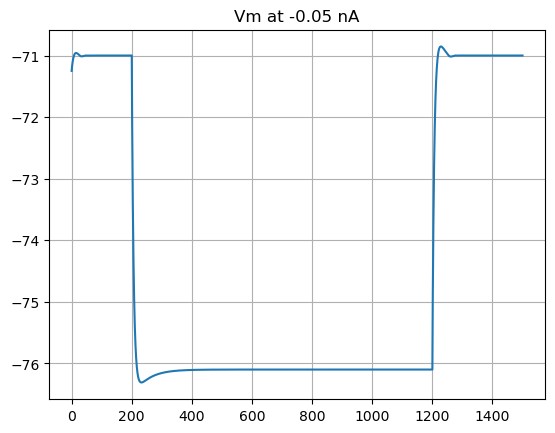

Desired Properties:       R_in=98.9, tau1=5.9, tau2=??.?, sag_ratio=0.960, V_rest=-71.25
GettablePassiveProperties(R_in=106.18941416905784, tau1=5.8500000000000005, tau2=53.0, sag_ratio=0.039545788082141105, V_rest=-71.00000125720949)


In [18]:
#modify simulation parameters if needed
sim_params['stim_amp'] = -0.05

sim_params['stim_delay'] = 200
sim_params['stim_dur'] = 1000
sim_params['h_tstop'] = 1500

#rebuild the cell to make sure the set_simulation() is using the correct hobj
#if using hoc call with the hoc filename and cell name

soma_diam_multiplier = 6
hobject = build_cell(soma_diam_multiplier)
#hobject = build_cell(soma_diam_multiplier,using_hoc=True,'HYPO_TEMPLATE.hoc','HYPO')

print(f"Soma area: {hobject.soma[0](0.5).area()}")
print(f"Soma diam: {hobject.soma[0].diam}")

# run the simulation
h, stim = set_simulation(hobject,sim_params)
v = h.Vector().record(hobject.soma[0](0.5)._ref_v)
h.finitialize()
h.run()

#plot the result and display spike frequency
V = v.as_numpy()
T = np.arange(0,h.tstop+h.dt,h.dt)
# plt.ylim(-90,-0)
plt.plot(T,V)
plt.grid(True)
plt.title(f"Vm at {sim_params['stim_amp']} nA")
plt.show()



#find Rin, tau, sag ratio, and Vrest
print('Desired Properties:       R_in=98.9, tau1=5.9, tau2=??.?, sag_ratio=0.960, V_rest=-71.25')
print(ACTPassiveModule.compute_gpp(v.as_numpy(), h.dt, sim_params['stim_delay'], sim_params['stim_delay']+sim_params['stim_dur']-10, sim_params['stim_amp']))

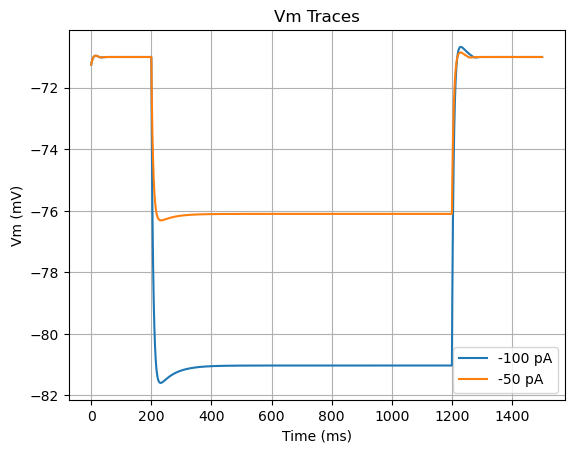

Desired Properties:       R_in=98.9, tau1=5.9, tau2=??.?, sag_ratio=0.960, V_rest=-71.25
GettablePassiveProperties(R_in=105.92967875351249, tau1=5.825, tau2=56.375, sag_ratio=0.053412603759501236, V_rest=-71.00000125720949)
GettablePassiveProperties(R_in=106.18941416905784, tau1=5.8500000000000005, tau2=53.0, sag_ratio=0.039545788082141105, V_rest=-71.00000125720949)


In [20]:
sim_amps = [-100, -50]
sim_params['stim_delay'] = 200
sim_params['stim_dur'] = 1000
sim_params['h_tstop'] = 1500

soma_diam_multiplier = 3.5
soma_diam_multiplier = 6
# soma_diam_multiplier = 10.5


# --- First simulation ---
sim_params['stim_amp'] = sim_amps[0] / 1000
hobj1 = build_cell(soma_diam_multiplier)
h, stim = set_simulation(hobj1, sim_params)
v1 = h.Vector().record(hobj1.soma[0](0.5)._ref_v)
tvec = h.Vector().record(h._ref_t)  # record time once
h.finitialize()
h.run()
V1 = np.array(v1)
T = np.array(tvec)

# --- Second simulation ---
sim_params['stim_amp'] = sim_amps[1] / 1000
hobj2 = build_cell(soma_diam_multiplier)
h, stim = set_simulation(hobj2, sim_params)
v2 = h.Vector().record(hobj2.soma[0](0.5)._ref_v)
h.finitialize()
h.run()
V2 = np.array(v2)

# --- Plotting both ---
plt.plot(T, V1, label=f"{sim_amps[0]} pA")
plt.plot(T, V2, label=f"{sim_amps[1]} pA")
plt.grid(True)
plt.xlabel("Time (ms)")
plt.ylabel("Vm (mV)")
plt.title("Vm Traces")
plt.legend()
plt.show()



#find Rin, tau, sag ratio, and Vrest
print('Desired Properties:       R_in=98.9, tau1=5.9, tau2=??.?, sag_ratio=0.960, V_rest=-71.25')
print(ACTPassiveModule.compute_gpp(v1.as_numpy(), h.dt, sim_params['stim_delay'], sim_params['stim_delay']+sim_params['stim_dur']-10, sim_amps[0]/1000))
print(ACTPassiveModule.compute_gpp(v2.as_numpy(), h.dt, sim_params['stim_delay'], sim_params['stim_delay']+sim_params['stim_dur']-10, sim_amps[1]/1000))

## Tuning Active Properties

1. Single Sim with Current Traces

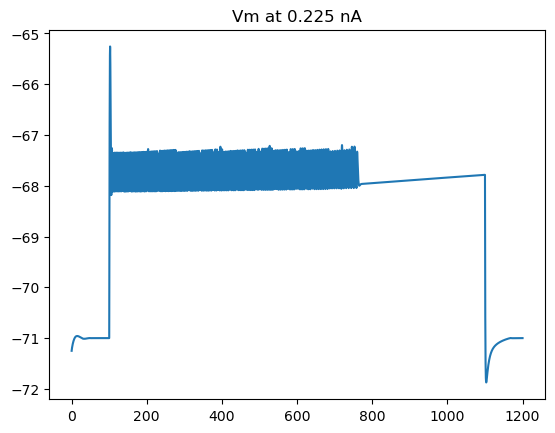

spike frequency = 0.00 Hz


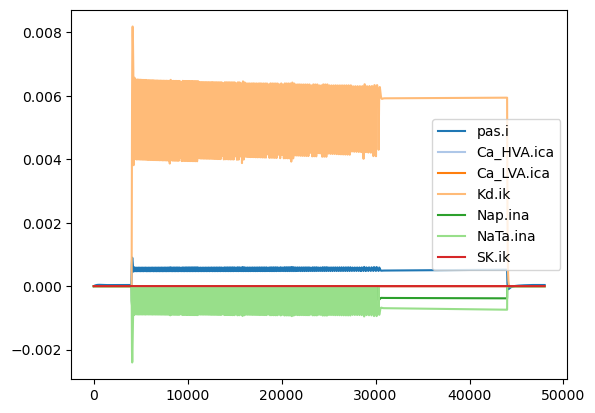

In [22]:
#modify simulation parameters if needed
sim_params['stim_amp'] = 0.225

sim_params['stim_delay'] = 100
sim_params['stim_dur'] = 1000
sim_params['h_tstop'] = sim_params['stim_delay'] + sim_params['stim_dur'] + 100

#rebuild the cell to make sure the set_simulation() is using the correct hobj
#if using hoc call with the hoc filename and cell name

# soma_diam_multiplier = 3.5
soma_diam_multiplier = 6
# soma_diam_multiplier = 10.5

hobject = build_cell(soma_diam_multiplier)
#hobject = build_cell(soma_diam_multiplier,using_hoc=True,'HYPO_TEMPLATE.hoc','HYPO')

# run the simulation
h, stim = set_simulation(hobject,sim_params)
v = h.Vector().record(hobject.soma[0](0.5)._ref_v)
current_recording_vars = get_rec_vars_for_i_in_sec(hobject.soma[0],0.5)
h.finitialize()
h.run()

#plot the result and display spike frequency
V = v.as_numpy()
T = np.arange(0,h.tstop+h.dt,h.dt)
plt.plot(T,V)
# plt.xlim(75,175)
# plt.ylim(-80,-60)
plt.title(f"Vm at {sim_params['stim_amp']} nA")
plt.show()

print(f"spike frequency = {get_frequency(v,sim_params):.2f} Hz")


currents_plotted = ['pas.i','Ca_HVA.ica','Ca_LVA.ica','Kd.ik','Nap.ina','NaTa.ina', 'SK.ik']
# currents_plotted = ['Ca_HVA.ica','Ca_LVA.ica', 'SK.ik','Nap.ina']

colors = plt.cm.tab20.colors  # 20 distinct colors
i = 0
for current in current_recording_vars:
  if current in currents_plotted:
    plt.plot(current_recording_vars[current].as_numpy(),color = colors[i],label = current)
    i+=1
plt.legend()

2. Multi-Sim Plot

Desired Properties:       R_in=98.9, tau1=5.9, tau2=??.?, sag_ratio=0.960, V_rest=-71.25
GettablePassiveProperties(R_in=0.10618941416905785, tau1=5.8500000000000005, tau2=53.0, sag_ratio=0.039545788082141105, V_rest=-71.00000125720949)
Desired Properties:       R_in=98.9, tau1=5.9, tau2=??.?, sag_ratio=0.960, V_rest=-71.25
GettablePassiveProperties(R_in=0.10592967875351249, tau1=5.825, tau2=56.375, sag_ratio=0.053412603759501236, V_rest=-71.00000125720949)


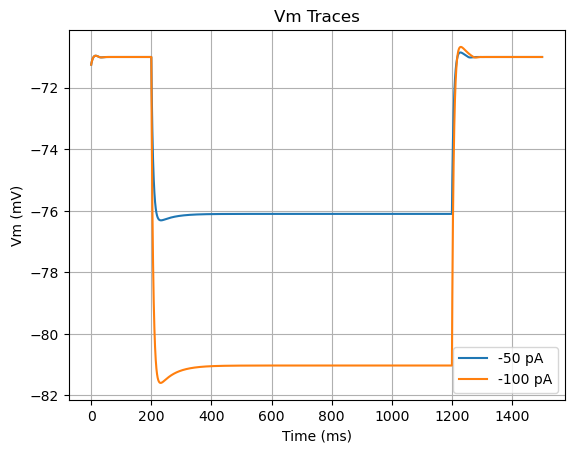

In [23]:
sim_amps = [-50,-100]
# sim_amps = [0.1, 0.15, 0.2, 0.25, 0.3]
sim_params['stim_delay'] = 200
sim_params['stim_dur'] = 1000
sim_params['h_tstop'] = 1500

soma_diam_multiplier = 6 # 3.5/6/10.5

V_traces = {}
spike_freqs = {}

for idx, amp_val in enumerate(sim_amps):
    sim_params['stim_amp'] = amp_val/1000
    hobj = build_cell(soma_diam_multiplier)
    h, stim = set_simulation(hobj, sim_params)

    v = h.Vector().record(hobj.soma[0](0.5)._ref_v)
    if idx == 0:
        tvec = h.Vector().record(h._ref_t)

    h.finitialize()
    h.run()

    V = np.array(v)
    V_traces[amp_val] = V
    T = np.array(tvec)

    f = get_frequency(v, sim_params)
    spike_freqs[amp_val] = f
    plt.plot(T, V, label=f"{amp_val} pA")

    if amp_val <0:
        print('Desired Properties:       R_in=98.9, tau1=5.9, tau2=??.?, sag_ratio=0.960, V_rest=-71.25')
        print(ACTPassiveModule.compute_gpp(v.as_numpy(), h.dt, sim_params['stim_delay'], sim_params['stim_delay']+sim_params['stim_dur']-10, amp_val))
    
    else:
        print(f"{amp_val} pA spike frequency = {f:.2f} Hz")

plt.grid(True)
plt.xlabel("Time (ms)")
# plt.xlim(150,500)
plt.ylabel("Vm (mV)")
# plt.ylim(-80,40)
plt.title("Vm Traces")
plt.legend()
plt.show()


In [29]:
# amps = list(spike_freqs.keys())
# freqs = list(spike_freqs.values())

# plt.plot(amps, freqs, marker='o')
# plt.title("PV FI CURVE")
# plt.xlabel("Stimulus Amplitude (nA)")
# plt.ylabel("Frequency (Hz)")
# plt.grid()
# plt.show()

3. Generate FI Curve

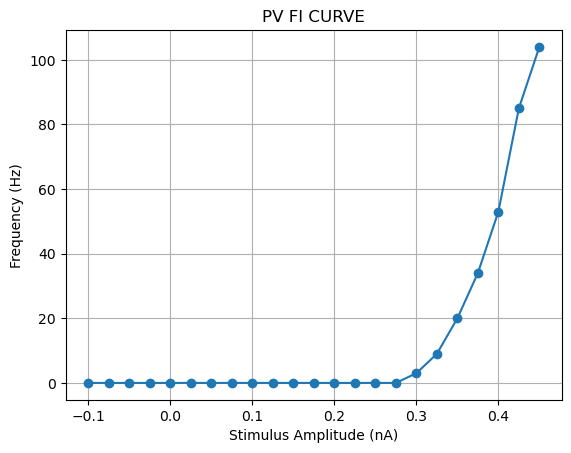

-0.1: 0
-0.075: 0
-0.05: 0
-0.025: 0
0.0: 0
0.025: 0
0.05: 0
0.075: 0
0.1: 0
0.125: 0
0.15: 0
0.175: 0
0.2: 0
0.225: 0
0.25: 0
0.275: 0
0.3: 3.0
0.325: 9.0
0.35: 20.0
0.375: 34.0
0.4: 53.0
0.425: 85.0
0.45: 104.0


In [25]:
#modify simulation parameters if needed
sim_params['stim_delay'] = 100
sim_params['stim_dur'] = 1000
sim_params['h_tstop'] = sim_params['stim_delay'] + sim_params['stim_dur'] + 100

#test the cell at multiple frequencies to get an FI curve

frequenies = []
amps = [-0.1, -0.075, -0.05,-0.025,0.0,0.025,0.05,0.075, 0.1,0.125, 0.15,0.175, 0.2, 0.225, 0.25, 0.275, 0.3,0.325,0.35,0.375,0.4, 0.425,0.45] #,0.475, 0.5]
# amps = [0.0,0.05, 0.1, 0.15, 0.2, 0.25, 0.3]#,0.325,0.35,0.375,0.4, 0.425,0.45] #,0.475, 0.5]


for amp in amps:
  #if using hoc call with the hoc filename and cell name
    hobject = build_cell(soma_diam_multiplier)
    #hobject = build_cell(soma_diam_multiplier,using_hoc=True,'HYPO_TEMPLATE.hoc','HYPO')

    sim_params['stim_amp'] = amp
    h, stim = set_simulation(hobject,sim_params)
    v = h.Vector().record(hobject.soma[0](0.5)._ref_v)
    h.finitialize()
    h.run()
    frequenies.append(get_frequency(v,sim_params))


plt.plot(amps, frequenies, marker='o')
plt.title("PV FI CURVE")
plt.xlabel("Stimulus Amplitude (nA)")
plt.ylabel("Frequency (Hz)")
plt.grid()
plt.show()


for a, f in zip(amps, frequenies):
    print(f"{a}: {f}")
